# HOSPITAL READMISSION MODEL

# Step1. Business Understanding
Diabetes is one of the most serious and widespread chronic diseases in the world. According to the International Diabetes Federation, over 537 million adults were living with diabetes in 2021. In the United States alone, diabetes accounted for 32% of all hospital readmissions in 2018, making it one of the leading causes of rehospitalization alongside heart failure and septicemia.Many diabetic patients require continuous monitoring after discharge, and some experience complications that result in readmission shortly after leaving the hospital.

Frequent readmissions increase healthcare costs, place additional strain on hospital resources, and may indicate gaps in patient care, discharge planning, or follow-up treatment. By identifying patients who are at a higher risk of being readmitted, healthcare providers can intervene early through follow-up appointments, patient education, medication management, and other preventive measures.

## Problem Statement
Hospitals currently have no reliable, data-driven system to identify which diabetic patients are likely to be readmitted within 30 days. This means:
High-risk patients are discharged without additional support or monitoring
Hospitals face financial penalties for high readmission rates
Patients suffer unnecessary complications that could have been prevented

## Business Objective
Machine learning provides an opportunity to solve this. This project aims at building a machine learning model that will predict whether diabetic patients will be readmitted to the hospital within 30 days of discharge, using information available at the time of discharge such as: Patient demographic(Age, Race, Gender), Clinical details(Diagnosis, Lab Results, Time spent in hospital), Medication history, Admission and discharge details.

## Step 2. Data Preparation

## 2.1 Importing all the required libraries
Before we do the data preparation , we are going to import all the necessarry libraries required to complete this project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")   # makes charts look cleaner by default
pd.set_option('display.max_columns', None)  # so pandas doesn't hide columns when printing

## 2.2 Loading the dataset
Here we are loading the dataset so we can start working with it.
After loading the dataset we will start exploring the data by checking the shape of the data, i.e the number of rows and columns, the information and the description, 

In [2]:
df = pd.read_csv('hospital_readmissions_30k.csv')
print(df.shape)

(30000, 12)


## 2.2 Initial data inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [4]:
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [5]:
df.describe(include='all').T

for c in ['gender', 'diabetes', 'hypertension', 'discharge_destination', 'readmitted_30_days']:
    print(c, df[c].unique())

gender ['Other' 'Female' 'Male']
diabetes ['Yes' 'No']
hypertension ['No' 'Yes']
discharge_destination ['Nursing_Facility' 'Home' 'Rehab']
readmitted_30_days ['Yes' 'No']


## 2.4 Data cleaning
We check the dataset for common problems like duplicated records, missing information, and values that don't make sense.


### 2.4.1 Checking duplicate records to prevent our numbers form looking bigger or skewed.


In [6]:
full_dupes = df.duplicated().sum()
id_dupes = df['patient_id'] .duplicated().sum()

print(f"fully duplicated rows: {full_dupes}")
print(f"duplicated patient IDs: {id_dupes}")

fully duplicated rows: 0
duplicated patient IDs: 0


In [7]:
df = df.drop_duplicates()
df = df.drop_duplicates(subset='patient_id', keep='first')

### 2.4.2 Checking for missing values

In [8]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

In [9]:
print("Missing values per column:")
print(df.isnull().sum())

placeholder_values = ['NA', 'N/A', 'na', 'n/a', 'Unknown', 'UNKNOWN', '?', '-', '', 'None', 'null']
print("\nRows with placeholder text per column:")
for c in df.select_dtypes(include='object').columns:
    hits = df[c].isin(placeholder_values).sum()
    if hits:
        print(f"  {c}: {hits}")

Missing values per column:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

Rows with placeholder text per column:


### 2.4.3 Checking for numerical and categorical columns

In [10]:
numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']
for c in numeric_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

cat_cols = ['gender', 'diabetes', 'hypertension', 'discharge_destination', 'readmitted_30_days']
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode()[0])

### 2.4.4 Checking for outliers and errors

In [11]:
numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

# quick range check
for c in numeric_cols:
    print(f"{c}: min={df[c].min()}, max={df[c].max()}")

age: min=18, max=90
cholesterol: min=150, max=300
bmi: min=18.0, max=40.0
medication_count: min=0, max=10
length_of_stay: min=1, max=10


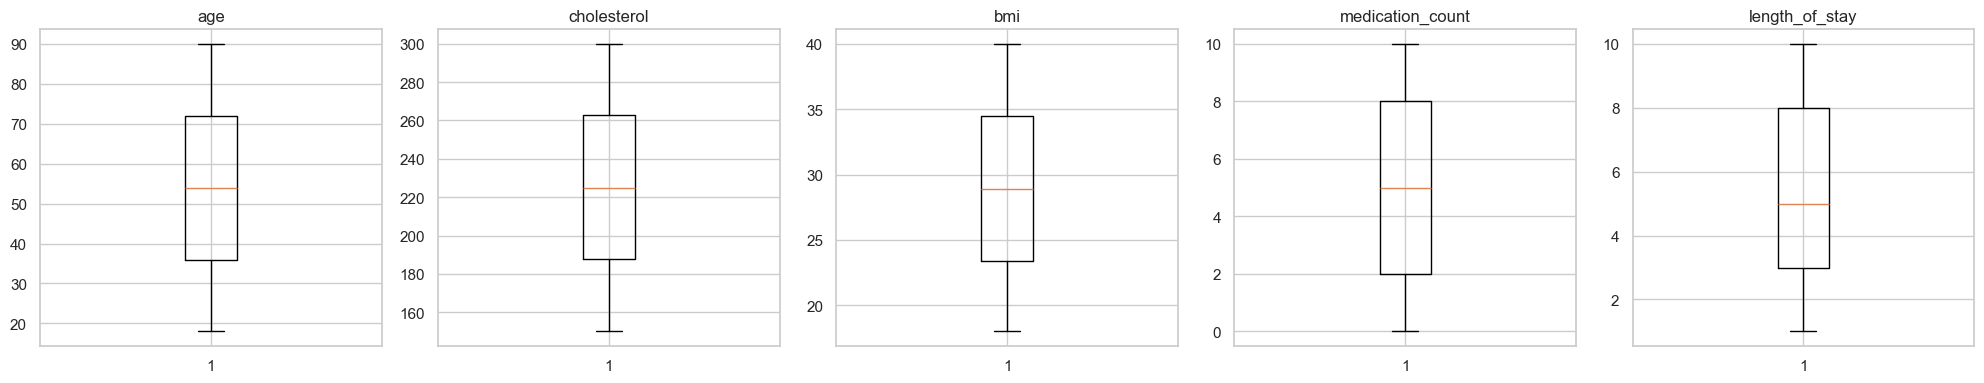

In [12]:
#visual check with boxplots - points far from the box are outliers
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax , c in zip(axes, numeric_cols):
    ax.boxplot(df[c])
    ax.set_title(c)
plt.tight_layout()
plt.show()    

In [13]:
#doing a statistical check using the interquartile rule 

def count_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for c in numeric_cols:
    print(f"{c}: {count_outliers(df[c])} outliers")

age: 0 outliers
cholesterol: 0 outliers
bmi: 0 outliers
medication_count: 0 outliers
length_of_stay: 0 outliers


In [14]:
# check blood pressure is always in the expected "systolic/diastolic" format,
# and that the numbers themselves are medically plausible
bp_split = df['blood_pressure'].str.extract(r'^(?P<systolic>\d+)/(?P<diastolic>\d+)$').astype(float)
bad_format = bp_split.isnull().any(axis=1).sum()
implausible = (
    (bp_split['systolic'] < 60) | (bp_split['systolic'] > 250) |
    (bp_split['diastolic'] < 30) | (bp_split['diastolic'] > 150)
).sum()

print(f"Blood pressure entries not in the expected format: {bad_format}")
print(f"Blood pressure entries outside a plausible range: {implausible}")

Blood pressure entries not in the expected format: 0
Blood pressure entries outside a plausible range: 0


## 2.4.5 Fixing the data formats
Since the blood pressure is stored as single piece of text file, combining the two separate numbers into one field, we are going to split it into systolic and diastolic as their own numerical columns before we proceed.
And since we also have columns with "Yes" or "No" as texts, that is ; diabetes, hypertension and whether the patient was readmitted, we are going to convert them into 0s and 1s to make it usable for statistics and for modelling.

In [15]:
#splitting the blood pressure into two separate numeric columns
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['blood_pressure'])

df[['systolic_bp', 'diastolic_bp']].head()

,systolic_bp,diastolic_bp
0,130,72
1,120,92
2,135,78
3,123,80
4,135,84


In [16]:
df.head(15)

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp
0,1,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130,72
1,2,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120,92
2,3,89,Other,153,30.3,No,Yes,1,1,Home,No,135,78
3,4,84,Female,153,31.5,No,Yes,3,10,Home,No,123,80
4,5,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135,84
5,6,75,Female,194,33.5,No,Yes,0,10,Home,No,139,100
6,7,47,Male,168,27.1,No,Yes,5,8,Home,No,139,79
7,8,18,Other,210,26.3,No,No,5,2,Home,No,153,81
8,9,68,Male,218,30.4,No,Yes,3,8,Home,No,111,76
9,10,23,Female,186,21.3,No,No,3,3,Home,No,142,72


### 2.4.6 Normalization and scaling- Feature Transformation

Since our numeric columns currently sits on different scales, i.e , cholestrol in hundreds while medication count in single digits . We are going to create standardized versions of these columns , where every number is rescaled so they are all measured on the same footing , so as to prevent our models from viewing larger numbers as of more weight than they actually posess just because they are large.

We are going to keep the original columns too, so our charts and summaries still show real and meaningful numbers like the actual age or actual cholestrol.

In [17]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay',
              'systolic_bp', 'diastolic_bp']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[scale_cols])

scaled_df = pd.DataFrame(scaled_values, columns=[f"{c}_scaled" for c in scale_cols], index=df.index)
df = pd.concat([df, scaled_df], axis=1)

df[[f"{c}_scaled" for c in scale_cols]].head(10)

,age_scaled,cholesterol_scaled,bmi_scaled,medication_count_scaled,length_of_stay_scaled,systolic_bp_scaled,diastolic_bp_scaled
0,0.955340,0.338181,0.402284,-0.003874,-1.570459,-0.338645,-1.459778
1,-0.374439,1.531254,1.158416,-0.319697,-0.872927,-1.020252,0.781643
2,1.667721,-1.657921,0.213251,-1.267166,-1.570459,0.002158,-0.787351
3,1.430261,-1.657921,0.402284,-0.635520,1.568436,-0.815770,-0.563209
4,-1.039328,-0.464849,-1.661326,0.311949,-0.524161,0.002158,-0.114925
5,1.002832,-0.717229,0.717339,-1.582989,1.568436,0.274801,1.678212
6,-0.326947,-1.313766,-0.290837,-0.003874,0.870904,0.274801,-0.675280
7,-1.704218,-0.350130,-0.416859,-0.003874,-1.221693,1.229050,-0.451138
8,0.670387,-0.166580,0.229003,-0.635520,0.870904,-1.633697,-1.011493
9,-1.466757,-0.900779,-1.204497,-0.635520,-0.872927,0.479283,-1.459778


In [18]:
#Double checking
df[[f"{c}_scaled" for c in scale_cols]].describe().T[['mean', 'std']]

,mean,std
age_scaled,-5.234331e-17,1.000017
cholesterol_scaled,-1.033840e-16,1.000017
bmi_scaled,4.031146e-16,1.000017
medication_count_scaled,-1.203186e-16,1.000017
length_of_stay_scaled,-1.058709e-16,1.000017
systolic_bp_scaled,-3.079019e-17,1.000017
diastolic_bp_scaled,-7.932025e-16,1.000017


In [19]:
# converting Yes/No text columns into 0/1
binary_map = {'Yes': 1, 'No': 0}
for c in ['diabetes', 'hypertension', 'readmitted_30_days']:
    df[c] = df[c].map(binary_map)

df[['diabetes', 'hypertension', 'readmitted_30_days']].head()

,diabetes,hypertension,readmitted_30_days
0,1,0,1
1,0,0,0
2,0,1,0
3,0,1,0
4,0,1,0


In [20]:
#Saving the cleaned dataset

df.to_csv('hospital_readmissions_30k_cleaned.csv', index=False)
print(f"Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Saved cleaned dataset: 30000 rows, 20 columns


## 3.Exploratory Data Analysis(EDA)

In this step we are exploring the cleaned data set to understand the distribution of variables ,identify patterns  and relationships, and examine factors that may be associated with hospital readmission within 30days.

### 3.0 Numerical variables- univariate analysis

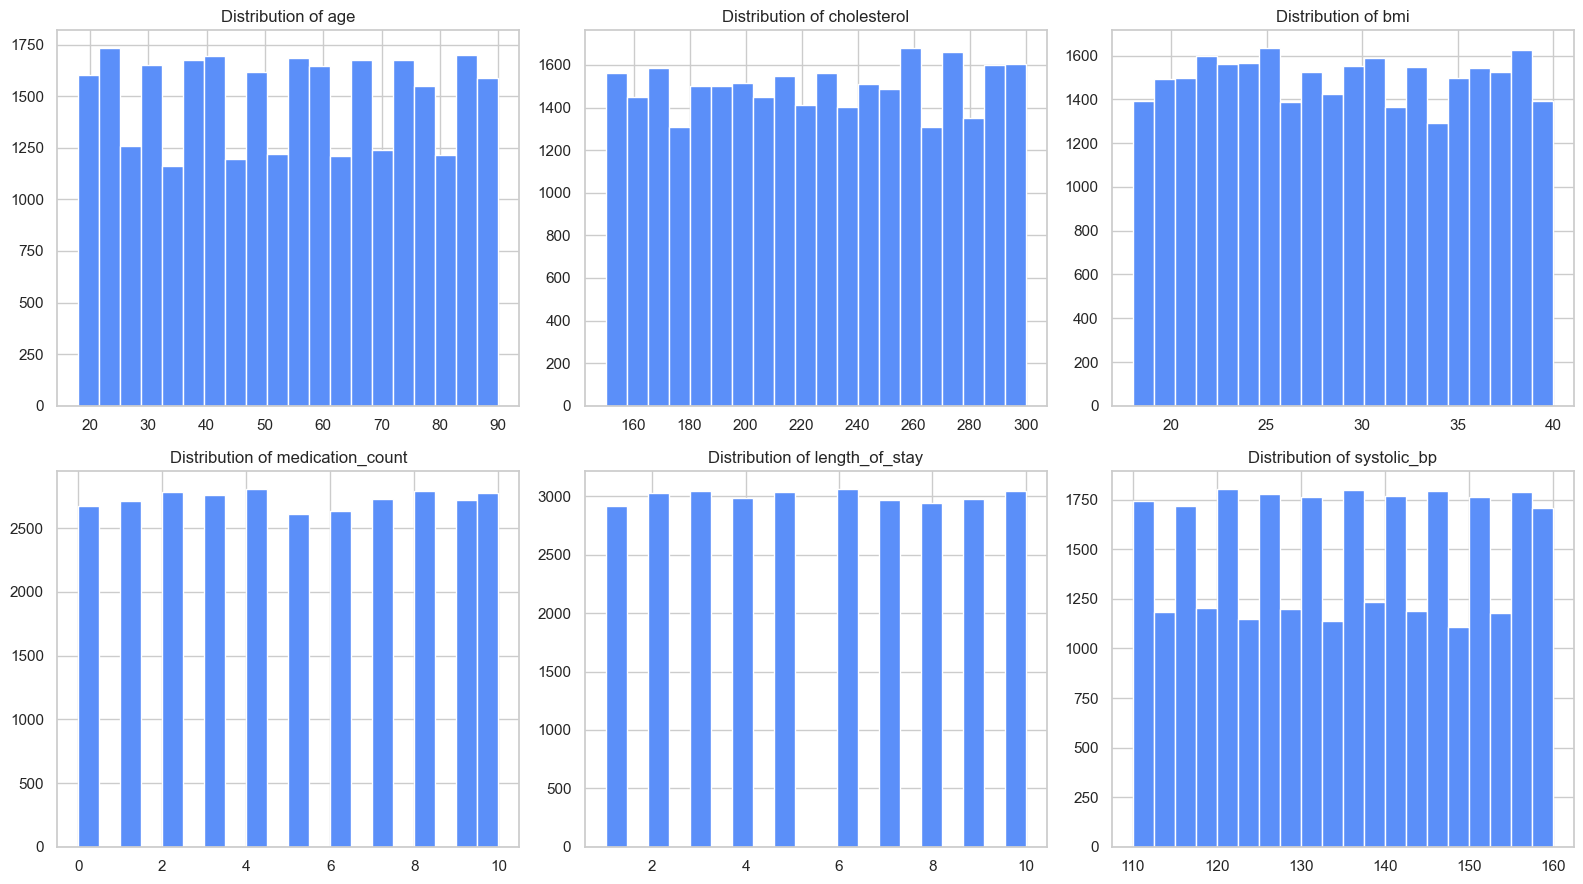

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

dist_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'systolic_bp']

for ax, c in zip(axes, dist_cols):
    ax.hist(df[c], bins=20, color='#5B8FF9', edgecolor='white')
    ax.set_title(f"Distribution of {c}")

plt.tight_layout()
plt.show()

### 3.1 Feature Engineering
In this step we will be doing feature engineering, that is; creating new columns that will group the existing information into more meaningful buckets. We will feature engineer the raw data to improve the performance of our machine learning model. For example turning the age into age gap groups like 51 - 75, or flag patients who are on an unusually high number of medications.
The new columns often reveal patterns more clearly than using raw numbers alone , and they will make our charts easier to read later.


In [22]:
import numpy as np

# group age into bands
df['age_group'] = pd.cut(
    df['age'], bins=[17, 30, 45, 60, 75, 90],
    labels=['18-30', '31-45', '46-60', '61-75', '76-90']
)

df[['age', 'age_group']].head(10)


,age,age_group
0,74,61-75
1,46,46-60
2,89,76-90
3,84,76-90
4,32,31-45
5,75,61-75
6,47,46-60
7,18,18-30
8,68,61-75
9,23,18-30


In [23]:
# group BMI into standard weight categories
df['bmi_category'] = pd.cut(
    df['bmi'], bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df[['bmi', 'bmi_category']].head(10)

,bmi,bmi_category
0,31.5,Obese
1,36.3,Obese
2,30.3,Obese
3,31.5,Obese
4,18.4,Underweight
5,33.5,Obese
6,27.1,Overweight
7,26.3,Overweight
8,30.4,Obese
9,21.3,Normal


In [24]:
# classify blood pressure into standard categories
def bp_stage(row):
    s, d = row['systolic_bp'], row['diastolic_bp']
    if s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    elif s < 140 or d < 90:
        return 'Hypertension_Stage1'
    else:
        return 'Hypertension_Stage2'

df['bp_category'] = df.apply(bp_stage, axis=1).astype('category')

df[['systolic_bp', 'diastolic_bp', 'bp_category']].head(10)

,systolic_bp,diastolic_bp,bp_category
0,130,72,Hypertension_Stage1
1,120,92,Hypertension_Stage1
2,135,78,Hypertension_Stage1
3,123,80,Hypertension_Stage1
4,135,84,Hypertension_Stage1
5,139,100,Hypertension_Stage1
6,139,79,Hypertension_Stage1
7,153,81,Hypertension_Stage1
8,111,76,Normal
9,142,72,Hypertension_Stage1


In [25]:
# flag patients on a high number of medications, and count how many conditions they have
df['high_med_count'] = (df['medication_count'] >= 6).astype(int)
df['comorbidity_count'] = df['diabetes'] + df['hypertension']

df[['medication_count', 'high_med_count', 'diabetes', 'hypertension', 'comorbidity_count']].head(10)

,medication_count,high_med_count,diabetes,hypertension,comorbidity_count
0,5,0,1,0,1
1,4,0,0,0,0
2,1,0,0,1,1
3,3,0,0,1,1
4,6,1,0,1,1
5,0,0,0,1,1
6,5,0,0,1,1
7,5,0,0,0,0
8,3,0,0,1,1
9,3,0,0,0,0


### 3.2 Categorical Variables - Univariate Analysis

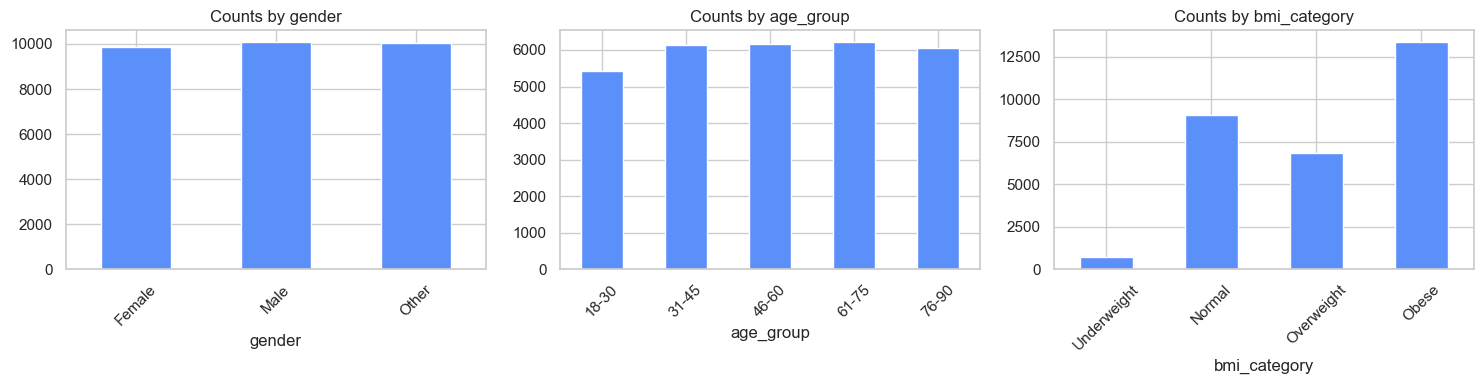

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, c in zip(axes, ['gender', 'age_group', 'bmi_category']):
    df[c].value_counts().sort_index().plot(kind='bar', ax=ax, color='#5B8FF9')
    ax.set_title(f"Counts by {c}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

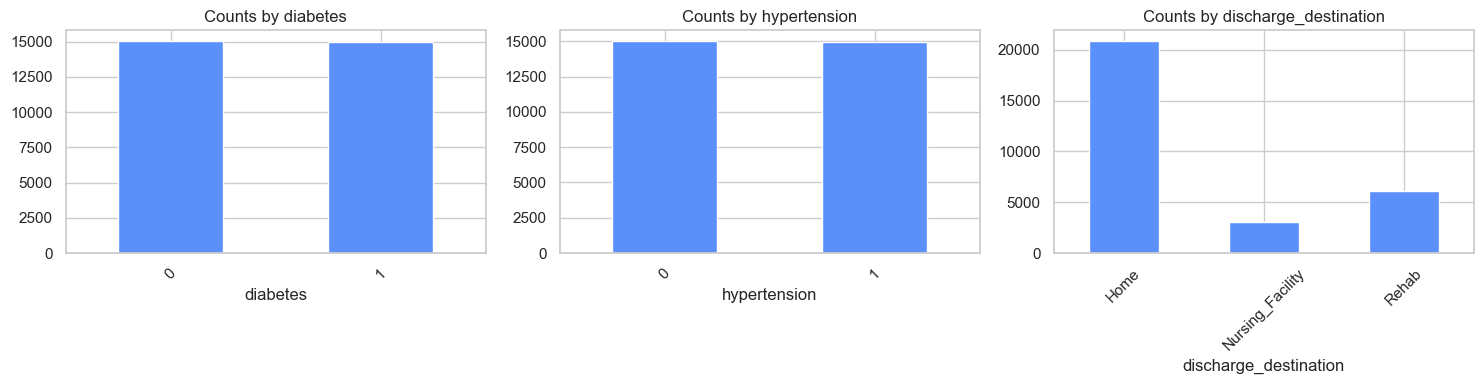

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, c in zip(axes, ['diabetes', 'hypertension', 'discharge_destination']):
    df[c].value_counts().sort_index().plot(kind='bar', ax=ax, color='#5B8FF9')
    ax.set_title(f"Counts by {c}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

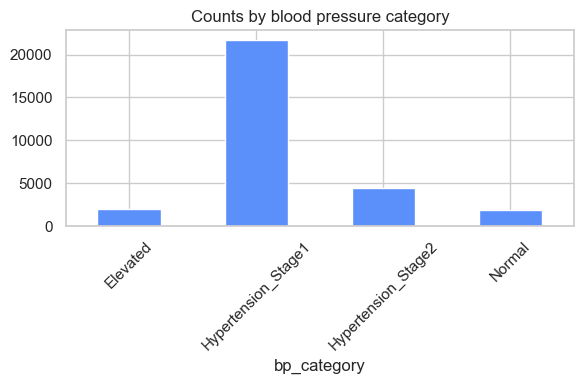

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
df['bp_category'].value_counts().sort_index().plot(kind='bar', color='#5B8FF9', ax=ax)
ax.set_title('Counts by blood pressure category')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Target Variable Analysis
We will check class balance in this step.
Since readmitted within 30 days is the outcome we want to understand and predict, its important we check how balanced it is before continue.
If it says, 90% of patients wer not readmitted and only 10% were , the imbalance matters.


In [29]:
counts = df['readmitted_30_days'].value_counts()
percentages = df['readmitted_30_days'].value_counts(normalize=True) * 100

print(counts)
print(percentages.round(2))

readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64
readmitted_30_days
0    87.75
1    12.25
Name: proportion, dtype: float64


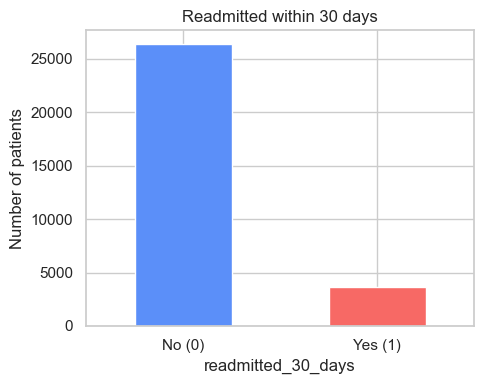

In [30]:
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', color=['#5B8FF9', '#F76965'], ax=ax)
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
ax.set_title('Readmitted within 30 days')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

### 3.4 Bivariate analysis

We will be comparing two variables at a time. This is to check how each patient characteristic relates to whether they were readmitted . 
This is where patterns that matter to the hospital starts to surface, like; does age play a role?, does gender ?, does having diabetes or hypertension increase the chance of readmission?

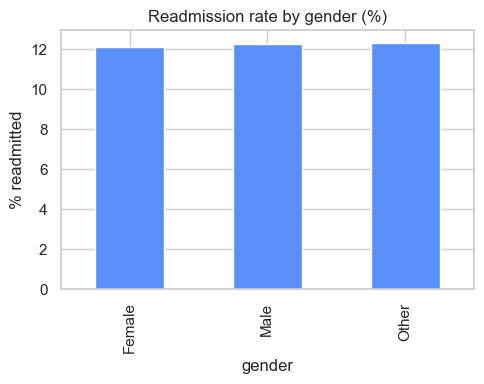

gender
Female    12.12
Male      12.29
Other     12.33
Name: readmitted_30_days, dtype: float64


In [31]:
# readmission rate by gender
readmit_by_gender = df.groupby('gender')['readmitted_30_days'].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
readmit_by_gender.plot(kind='bar', color='#5B8FF9', ax=ax)
ax.set_title('Readmission rate by gender (%)')
ax.set_ylabel('% readmitted')
plt.tight_layout()
plt.show()

print(readmit_by_gender.round(2))

C:\Users\User\AppData\Local\Temp\ipykernel_14908\322823636.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  readmit_by_age = df.groupby('age_group')['readmitted_30_days'].mean() * 100


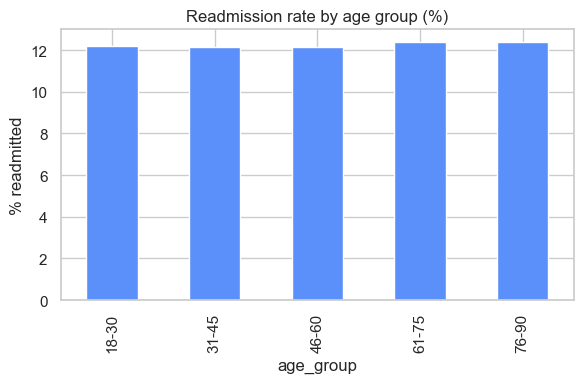

age_group
18-30    12.18
31-45    12.14
46-60    12.17
61-75    12.37
76-90    12.37
Name: readmitted_30_days, dtype: float64


In [32]:
# readmission rate by age group
readmit_by_age = df.groupby('age_group')['readmitted_30_days'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
readmit_by_age.plot(kind='bar', color='#5B8FF9', ax=ax)
ax.set_title('Readmission rate by age group (%)')
ax.set_ylabel('% readmitted')
plt.tight_layout()
plt.show()

print(readmit_by_age.round(2))

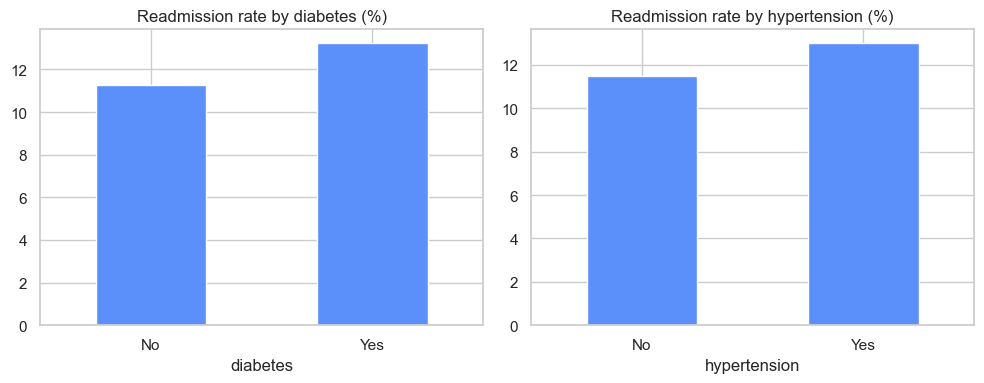

In [33]:
# readmission rate by diabetes and hypertension status
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby('diabetes')['readmitted_30_days'].mean().mul(100).plot(kind='bar', ax=axes[0], color='#5B8FF9')
axes[0].set_title('Readmission rate by diabetes (%)')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

df.groupby('hypertension')['readmitted_30_days'].mean().mul(100).plot(kind='bar', ax=axes[1], color='#5B8FF9')
axes[1].set_title('Readmission rate by hypertension (%)')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

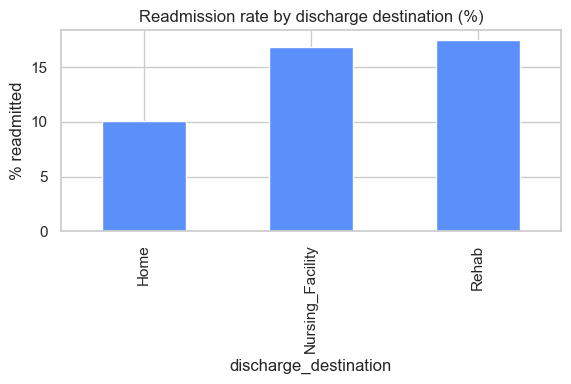

discharge_destination
Home                10.04
Nursing_Facility    16.85
Rehab               17.50
Name: readmitted_30_days, dtype: float64


In [34]:
readmit_by_discharge = df.groupby('discharge_destination')['readmitted_30_days'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
readmit_by_discharge.plot(kind='bar', color='#5B8FF9', ax=ax)
ax.set_title('Readmission rate by discharge destination (%)')
ax.set_ylabel('% readmitted')
plt.tight_layout()
plt.show()

print(readmit_by_discharge.round(2))

### 3.5 Multivariate Analysis
So far we've only looked at one factor at a time against readmission. But in reality, patient risk is usually shaped by a combination of things-an older patient with diabetes and a high medication count might carry more risk than any single factor on its own. In this step we look at how several numeric variables move together, using a correlation heatmap.
 This helps us spot which factors tend to rise and fall together, and gives us an early sense of which ones might matter most once we start building the prediction model.

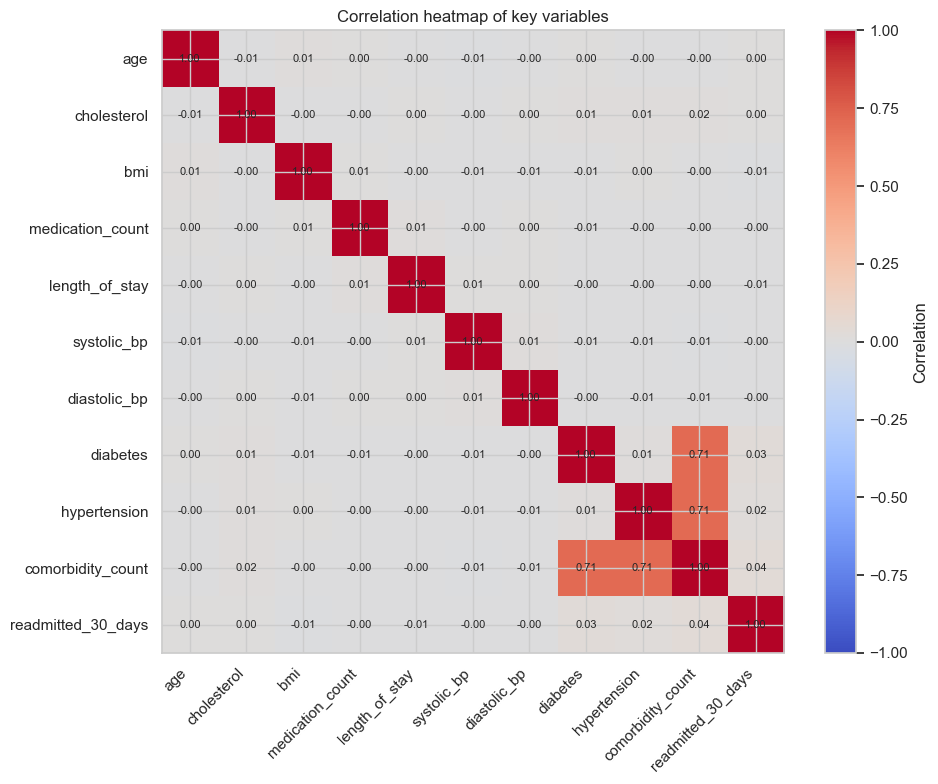

In [35]:
corr_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay',
             'systolic_bp', 'diastolic_bp', 'diabetes', 'hypertension',
             'comorbidity_count', 'readmitted_30_days']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='Correlation')
plt.title('Correlation heatmap of key variables')
plt.tight_layout()
plt.show()

## 4. Modelling phase

## 4.1 Fix the leakage & Split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
# load the cleaned dataset
df=pd.read_csv('hospital_readmissions_30k_cleaned.csv')
df.head()

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp,age_scaled,cholesterol_scaled,bmi_scaled,medication_count_scaled,length_of_stay_scaled,systolic_bp_scaled,diastolic_bp_scaled
0,1,74,Other,240,31.5,1,0,5,1,Nursing_Facility,1,130,72,0.955340,0.338181,0.402284,-0.003874,-1.570459,-0.338645,-1.459778
1,2,46,Female,292,36.3,0,0,4,3,Nursing_Facility,0,120,92,-0.374439,1.531254,1.158416,-0.319697,-0.872927,-1.020252,0.781643
2,3,89,Other,153,30.3,0,1,1,1,Home,0,135,78,1.667721,-1.657921,0.213251,-1.267166,-1.570459,0.002158,-0.787351
3,4,84,Female,153,31.5,0,1,3,10,Home,0,123,80,1.430261,-1.657921,0.402284,-0.635520,1.568436,-0.815770,-0.563209
4,5,32,Other,205,18.4,0,1,6,4,Nursing_Facility,0,135,84,-1.039328,-0.464849,-1.661326,0.311949,-0.524161,0.002158,-0.114925


In [4]:
# Drop patient's ID and pre scaled columns
scaled_cols_to_drop=[c for c in df.columns if c.endswith('_scaled')]
df_model= df.drop(columns=['patient_id'] + scaled_cols_to_drop)


In [5]:
# separate features and target variable
X= df_model.drop(columns=['readmitted_30_days'])
y= df_model['readmitted_30_days']

## 4.1 Data Splitting

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train readmission rate:", y_train.mean().round(4))
print("Test readmission rate:", y_test.mean().round(4))

Train shape: (24000, 11)  Test shape: (6000, 11)
Train readmission rate: 0.1225
Test readmission rate: 0.1225


#### we loaded the cleaned data, removed patient_id (not predictive) and the previously-scaled columns (since they were scaled on the full dataset — a leakage risk), then split into train/test using stratify=y so both sets kept the same 12.25% readmission rate. This ensures the test set is a fair, untouched "final exam" for whatever model we build, and that any scaling/encoding we now do is learned only from training data.

### 4.2 Data Preprocessing

In [7]:
# Confirm exact data types in X_train
print(X_train.dtypes)

age                        int64
gender                       str
cholesterol                int64
bmi                      float64
diabetes                   int64
hypertension               int64
medication_count           int64
length_of_stay             int64
discharge_destination        str
systolic_bp                int64
diastolic_bp               int64
dtype: object


since the engineered features are not available in this dataset we will add them

In [8]:
import numpy as np

def engineer_features(X):
    X = X.copy()
    X['age_group'] = pd.cut(X['age'], bins=[17, 30, 45, 60, 75, 90],
                             labels=['18-30', '31-45', '46-60', '61-75', '76-90'])
    X['bmi_category'] = pd.cut(X['bmi'], bins=[0, 18.5, 25, 30, np.inf],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    def bp_stage(row):
        s, d = row['systolic_bp'], row['diastolic_bp']
        if s < 120 and d < 80: return 'Normal'
        elif s < 130 and d < 80: return 'Elevated'
        elif s < 140 or d < 90: return 'Hypertension_Stage1'
        else: return 'Hypertension_Stage2'
    X['bp_category'] = X.apply(bp_stage, axis=1)
    X['high_med_count'] = (X['medication_count'] >= 6).astype(int)
    X['comorbidity_count'] = X['diabetes'] + X['hypertension']
    return X

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

In [10]:
# Define the pipeline
numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay',
                'systolic_bp', 'diastolic_bp', 'comorbidity_count']
binary_cols = ['diabetes', 'hypertension', 'high_med_count']
categorical_cols = ['gender', 'discharge_destination', 'age_group', 'bmi_category', 'bp_category']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('bin', 'passthrough', binary_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

we are using logistic regression as our baseline model

## 5.0 Fitting Phase

## 5.1 Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','gender','cholesterol',...,'bp_category','high_med_count', 'comorbidity_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

### 5.1.1 Model Evaluation


In [12]:
# import necessary libraries
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

# Predictions
y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:, 1]  # probability of class 1 (readmitted)



In [14]:
# Classification report: precision, recall, F1 per class
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.89      0.69      0.78      5265
           1       0.16      0.40      0.23       735

    accuracy                           0.66      6000
   macro avg       0.52      0.55      0.50      6000
weighted avg       0.80      0.66      0.71      6000



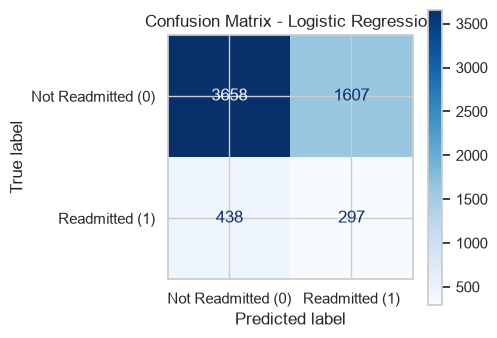

In [19]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Readmitted (0)', 'Readmitted (1)'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()


In [20]:
# ROC-AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.5627


this model catches 40% of actual readmissions. Better than random guessing on this class, but still misses 60% of true readmissions that means it is not great for a hospital that wants to flag at-risk patients. Out of everyone the model flags as "will be readmitted," only 16% actually are. That means for every true positive caught, there are roughly 5 false alarms. Additionally, the model correctly identifies 69% of patients who won't be readmitted.
The features we're using genuinely don't carry much signal about readmission or
Logistic regression specifically isn't capturing whatever relationship exists (e.g., if the real pattern is non-linear or an interaction between features) thus we will try a stronger model

### 5.2 Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])



## 5.2.1 Model Fitting

In [22]:
rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_pred_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]



## 5.2.2 Model Evaluation

In [23]:
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_rf), 4))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      5265
           1       0.15      0.01      0.03       735

    accuracy                           0.87      6000
   macro avg       0.51      0.50      0.48      6000
weighted avg       0.79      0.87      0.82      6000

ROC-AUC: 0.5634


Random Forest actually performs worse than Logistic Regression Model. Let us check the feature importance

## 5.2.3 Feature Importance- Random Forest Model

In [24]:
importances = rf_pipe.named_steps['classifier'].feature_importances_
feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(15))

num__cholesterol                        0.134315
num__bmi                                0.134062
num__systolic_bp                        0.118008
num__age                                0.116362
num__diastolic_bp                       0.109071
num__length_of_stay                     0.081168
num__medication_count                   0.078424
cat__discharge_destination_Rehab        0.022092
cat__gender_Male                        0.019438
cat__gender_Other                       0.019301
num__comorbidity_count                  0.019251
bin__high_med_count                     0.014238
cat__bp_category_Hypertension_Stage1    0.013622
bin__hypertension                       0.012534
cat__age_group_31-45                    0.012425
dtype: float64


In [25]:
train_check = X_train.select_dtypes(include=[np.number]).copy()
train_check['target'] = y_train.values

print(train_check.corr()['target'].sort_values(ascending=False))

target               1.000000
comorbidity_count    0.037080
diabetes             0.027504
hypertension         0.025222
cholesterol          0.009041
medication_count     0.002311
high_med_count       0.001974
age                  0.001590
diastolic_bp        -0.000192
length_of_stay      -0.003180
systolic_bp         -0.005956
bmi                 -0.014668
Name: target, dtype: float64


correlations below about ±0.1 are generally considered negligible in practical terms, and everything here is far under that. With the features available in this dataset, there is essentially no learnable relationship between patient characteristics and 30-day readmission. Let us try another model


## 5.3 Xgboost Model

In [26]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class balancing for XGBoost
# (ratio of negative to positive class in training data)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])


## 5.3.1 Model Fitting

In [27]:

xgb_pipe.fit(X_train, y_train)

y_pred_xgb = xgb_pipe.predict(X_test)
y_pred_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]


## 5.3.2 Model Evaluation

In [28]:

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      5265
           1       0.16      0.38      0.22       735

    accuracy                           0.68      6000
   macro avg       0.53      0.55      0.51      6000
weighted avg       0.80      0.68      0.73      6000

ROC-AUC: 0.556


## 6.0 Model Evaluation

We trained three classification models; Logistic Regression, Random Forest and XGBoost: to predict 30-day hospital readmissionof diabetic patients. All three models converged on a similar, weak result: ROC-AUC scores of 0.5627, 0.5634, and 0.556 respectively only marginally better than random guessing (0.5). 
This was proceeded by two further checks:
 correlation analysis showed every numeric feature had a relationship with the target under ±0.04
 Random Forest feature importances were flat across all features with no standout predictor. Because three fundamentally different algorithm types reached the same ceiling, this points to a limitation in the available features rather than in model choice or tuning. Demographic and single-visit clinical snapshots (age, BMI, cholesterol, blood pressure, medication count) appear insufficient to reliably predict readmission; stronger performance would likely require richer data such as prior admission history.